In [1]:
!nvidia-smi

Sat Apr  4 00:08:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.28.03              Driver Version: 560.28.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      On  |   00000000:3A:00.0 Off |                    0 |
| N/A   36C    P8             16W /   72W |       1MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
IN_COLAB = False
import os
import sys
import torch  # PyTorch import
import torch.nn as nn
from tqdm.notebook import tqdm  # tqdm for notebooks
import numpy as np
import matplotlib.pyplot as plt

# Enable GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Introducción a NeRF: Síntesis de Nuevas Vistas

La **síntesis de nuevas vistas** es la tarea de renderizar una escena 3D a partir de imágenes 2D tomadas desde diferentes vistas. La idea es ser capaz de generar nuevas vistas de una escena que no estaban en el conjunto de datos original.

### ¿Cómo resuelve NeRF este problema?
NeRF (Neural Radiance Fields) aprende una representación continua de una escena en 3D. Dado un conjunto de imágenes con poses conocidas (posiciones y orientaciones de la cámara), NeRF se entrena para predecir el color y la opacidad en cualquier punto del espacio.

NeRF tiene como objetivo reconstruir una representación volumétrica de la escena aproximando la **densidad del volumen** y la **radiancia emitida** en cada punto del espacio 3D.

Los componentes clave de NeRF incluyen:
1. **Codificación Posicional** de puntos 3D y direcciones de visualización.
2. **Multilayer Perceptron (MLP)** para modelar los campos de radiancia.
3. **Renderizado Volumétrico** para sintetizar imágenes acumulando radiancia a lo largo de los rayos.

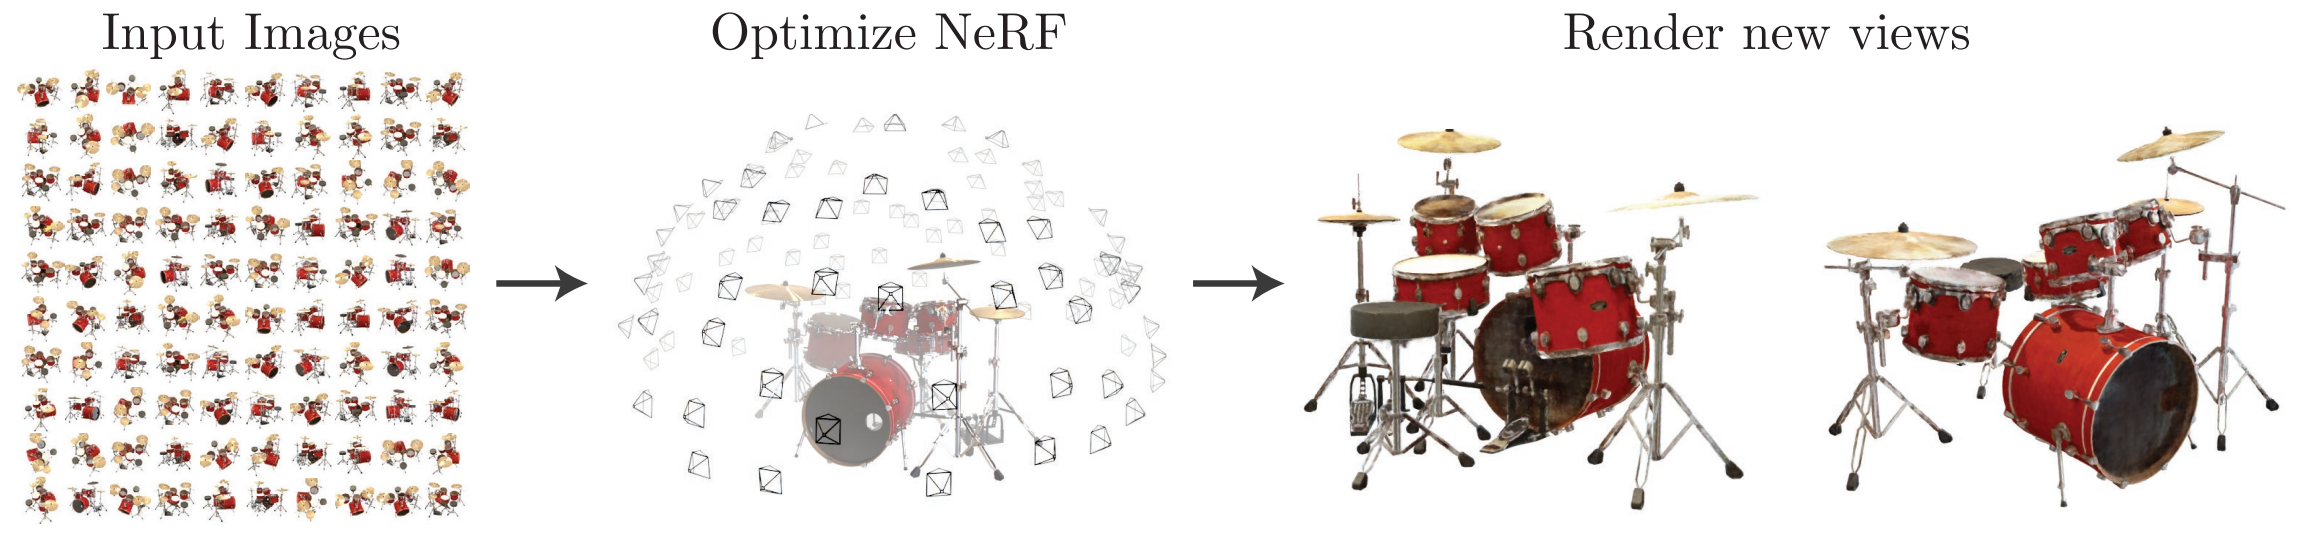


(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


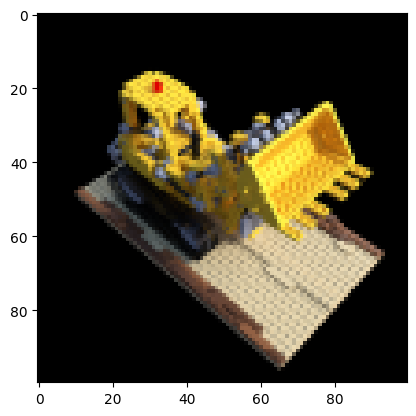

In [3]:
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]
print(images.shape, poses.shape, focal)

testimg, testpose = images[101], poses[101]
images = images[:100,...,:3]
poses = poses[:100]

plt.imshow(testimg)
plt.show()

# Arquitectura de NeRF

NeRF es esencialmente una **red neuronal** (Perceptrón Multicapa o MLP) que toma coordenadas 3D y direcciones de visualización y genera **color** (valores RGB) y **densidad**.

### Pasos:
1. **Entrada**: Un punto 3D **x** y una dirección de visualización **d**.
2. **Codificación Posicional**: Aplicar codificación posicional tanto a **x** como a **d**.
3. **MLP**: Pasar las entradas codificadas a través de una red neuronal (MLP).
   - La MLP genera densidad (escalar) y color (vector 3D) para cada punto.
4. **Renderizado Volumétrico**: Combinar las salidas de la MLP a lo largo del rayo para calcular el color final del píxel.

NeRF se basa en **muchas muestras** (cientos o miles de puntos 3D) para renderizar la imagen con precisión desde cada píxel. a continuación, la arquitectura interna del la MLP utilizada en NeRF


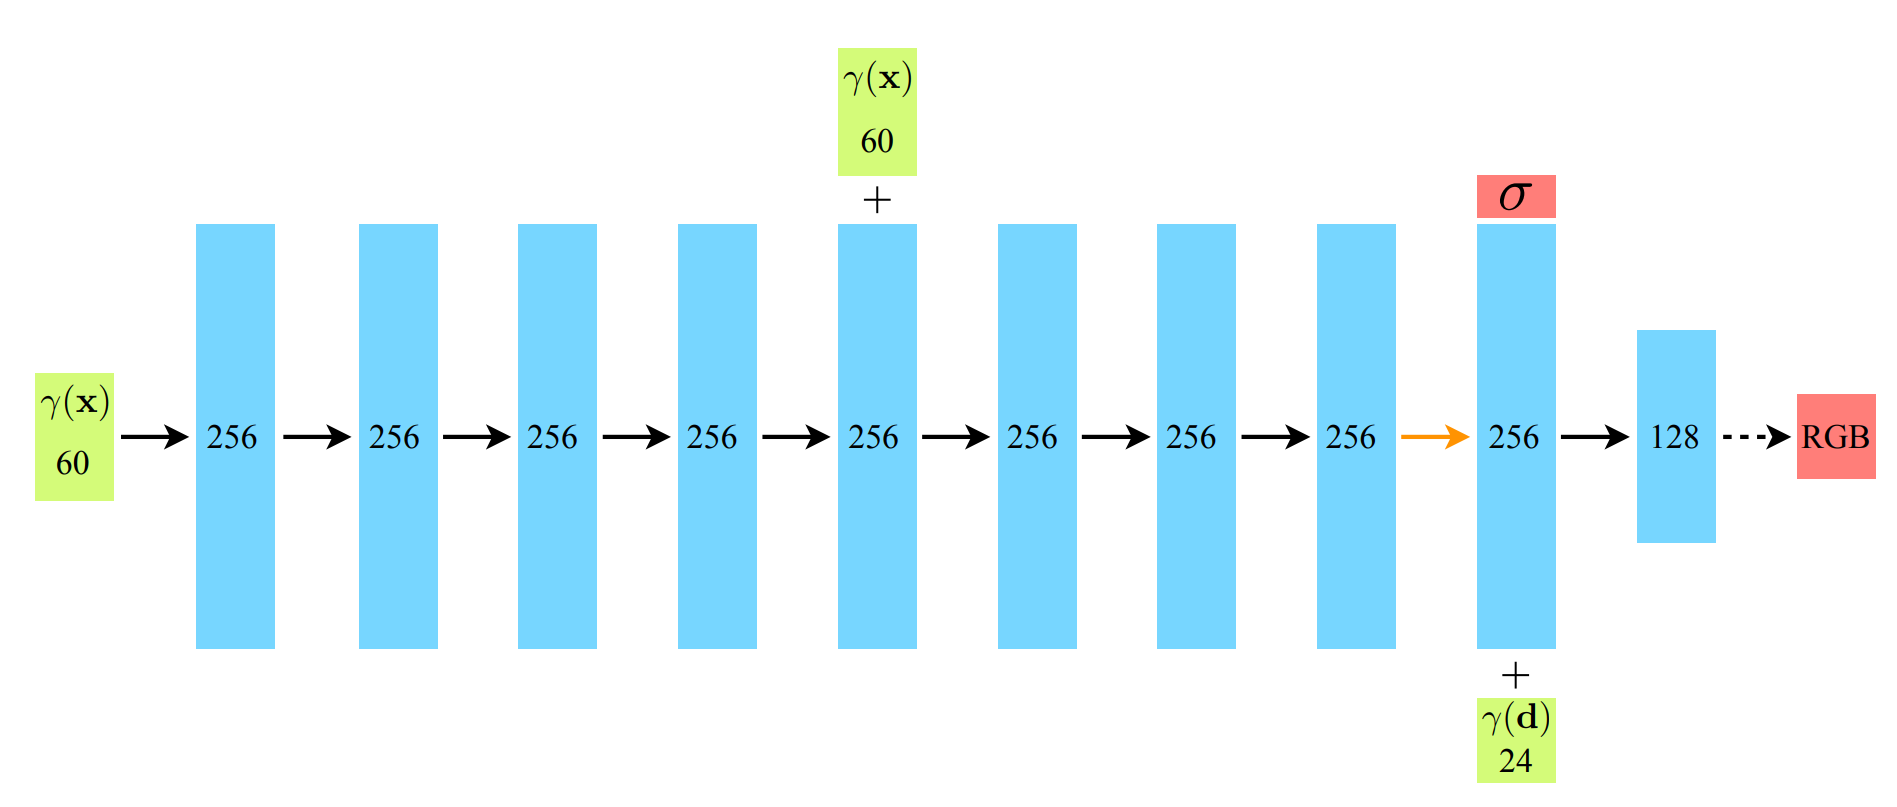


In [4]:
class TinyNerf(nn.Module):
    def __init__(self, D=8, W=256, L_embed=6):
        """
        D: Número de capas ocultas
        W: Número de neuronas por capa
        L_embed: Longitud de la codificación posicional
        """
        super(TinyNerf, self).__init__()

        self.L_embed = L_embed

        # Capas del modelo
        self.relu = nn.ReLU()

        # Lista para almacenar las capas lineales
        self.capas = nn.ModuleList()

        # Capa de entrada tiene dimensión 3 + 3*2*L_embed
        input_dim = 3 + 3 * 2 * L_embed

        # Crear capas ocultas (MLP)
        for i in range(D):
            if i == 0:
                # Primera capa, desde input_dim a W
                self.capas.append(nn.Linear(input_dim, W))
            elif i == 4:
                # En la 5ta capa, concatenamos la entrada original, así que la entrada debe ser input_dim + W
                self.capas.append(nn.Linear(W + input_dim, W))
            else:
                # Capas ocultas intermedias, todas de W -> W
                self.capas.append(nn.Linear(W, W))

        # Capa final que devuelve 4 valores (RGB y densidad)
        self.capa_final = nn.Linear(W, 4)

    def forward(self, x):
        """
        Forward pass del modelo. Toma la entrada x, que ya debe tener la codificación posicional aplicada.
        """
        input_inicial = x  # Guardar las entradas originales para concatenar más tarde

        # Pasar a través de las capas de la MLP
        for i, capa in enumerate(self.capas):
            x = self.relu(capa(x))  # Aplicar capa y función de activación

            # En la 5ta capa, concatenamos la entrada original con la salida actual
            if i == 3:
                x = torch.cat([x, input_inicial], dim=-1)  # Concatenar sobre la última dimensión

        # Capa final sin activación (para generar los 4 valores)
        x = self.capa_final(x)

        return x


# Codificación Posicional

NeRF usa **Codificación Posicional** para superar las limitaciones de las MLPs en la representación de detalles de alta frecuencia. Codifica puntos 3D y direcciones de visualización en un espacio de mayor dimensión, permitiendo que el modelo aprenda detalles finos.


Para un punto 3D $( \mathbf{x} )$, la codificación posicional es un conjunto de senos aplicados a diferentes frecuencias:
$$ \gamma(\mathbf{x}) = \left[ \sin(2^0 \pi \mathbf{x}), \cos(2^0 \pi \mathbf{x}), \sin(2^1 \pi \mathbf{x}), \cos(2^1 \pi \mathbf{x}), \ldots \right] $$



Al aplicar senos de diferentes frecuencias, ayudamos a que la MLP aprenda la estructura espacial de la escena de manera más efectiva.

La codificación posicional asegura que la red neuronal pueda aprender tanto las estructuras gruesas (detalles grandes) como las estructuras finas (detalles pequeños).


# Trazado de Rayos en NeRF

En NeRF, representamos la escena como un volumen 3D continuo. Para renderizar una imagen 2D, disparamos **rayos** a través de cada píxel de la imagen, originando desde la posición de la cámara.

Para cada rayo, NeRF calcula:
- **Puntos 3D** a lo largo del rayo.
- **Densidades del volumen** (cuánto se absorbe o emite luz en cada punto).
- **Valores de color RGB** (cuánta radiancia se emite en ese punto).

El proceso de renderizado acumula el color y la densidad a lo largo de cada rayo para sintetizar el valor final de píxel.

El **marching de rayos** es el proceso de muestrear puntos a lo largo de cada rayo y consultar la red neuronal para obtener los valores de RGB y densidad en cada punto.



# Renderizado Volumétrico

Una vez que tenemos el color y la densidad en diferentes puntos a lo largo de cada rayo, necesitamos calcular el color final del píxel. Esto se hace a través del **renderizado volumétrico**, que simula cómo interactúa la luz con la escena.

Para cada rayo, la ecuación de renderizado volumétrico calcula el color final del píxel acumulando los colores y densidades en los puntos muestreados a lo largo del rayo:
1. Calcular la distancia entre puntos a lo largo del rayo.
2. Para cada punto:
   - Calcular el **valor alpha** (la opacidad) usando la densidad en ese punto.
   - Calcular la contribución del punto al color final usando los valores de alpha y RGB.
3. Combinar las contribuciones de todos los puntos a lo largo del rayo.

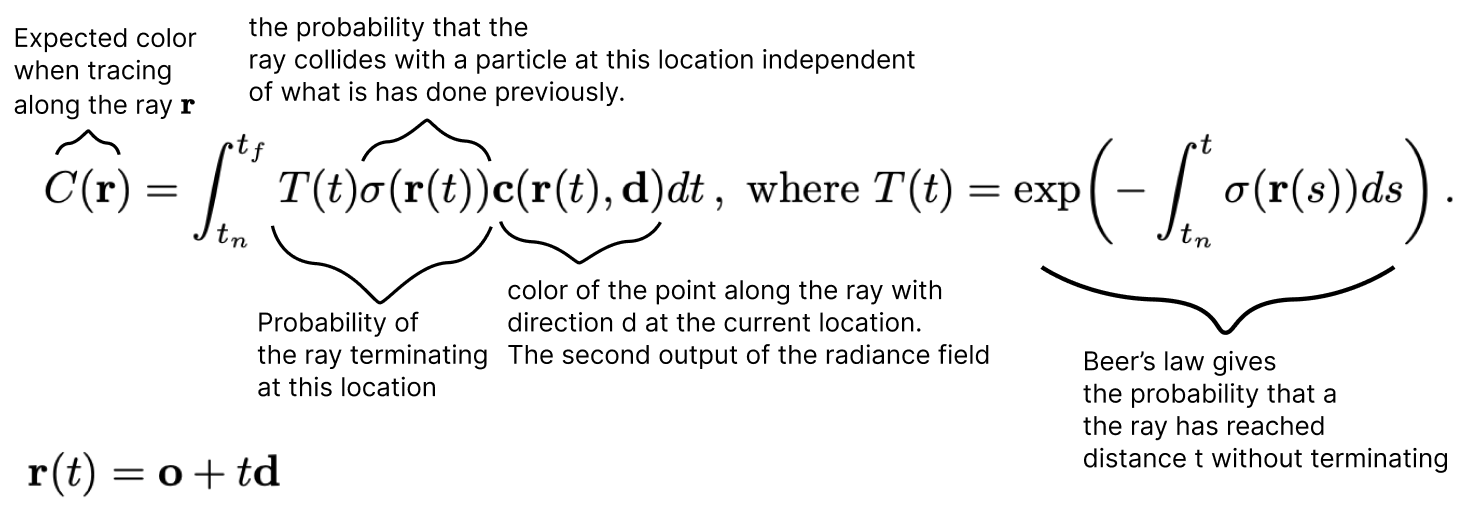

Esto nos da el color final del píxel, como si el rayo pasara a través de todo el volumen 3D.

La **transparencia** del volumen en un punto dado se determina por la cantidad de densidad presente en cada punto.


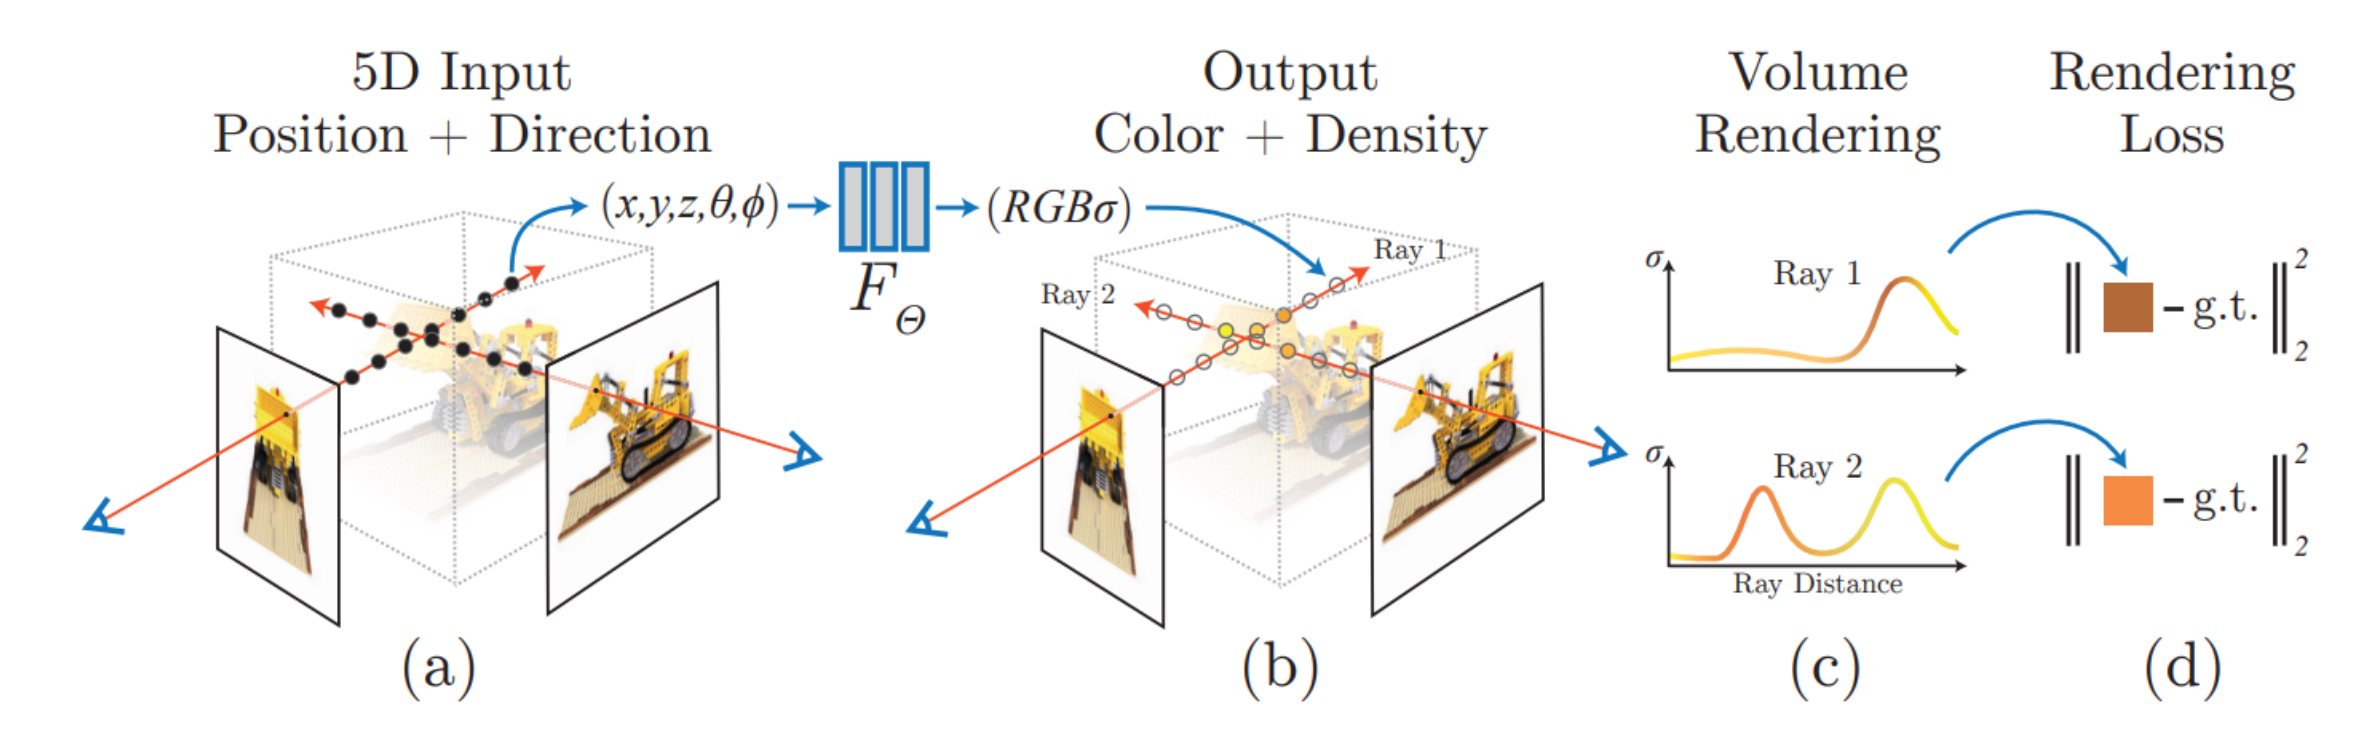



In [5]:
import torch
import torch.nn.functional as F

# Función de codificación posicional (posenc)
def codificacion_posicional(x):
    resultados = [x]  # Lista para guardar los resultados
    for i in range(L_embed):
        for fn in [torch.sin, torch.cos]:
            resultados.append(fn(2.0 ** i * x))  # Aplica sin y cos con diferentes frecuencias
    return torch.cat(resultados, -1)  # Concatena todas las codificaciones

# Parámetro de la cantidad de embeddings posicionales
L_embed = 6
# Asignamos la función de codificación posicional
fn_embed = codificacion_posicional


# Función para obtener los rayos
def obtener_rayos(altura, anchura, focal, c2w):
    """
    Altura: altura de la imagen
    Anchura: anchura de la imagen
    Focal: distancia focal de la cámara
    c2w: matriz de transformación de la cámara al mundo (debe estar en el dispositivo correcto)
    """
    # Asegurarnos de que todo esté en el mismo dispositivo que c2w
    device = c2w.device  # Obtener el dispositivo donde está la matriz c2w

    # Crear la cuadrícula i, j
    i, j = torch.meshgrid(torch.arange(anchura, dtype=torch.float32, device=device),
                          torch.arange(altura, dtype=torch.float32, device=device),
                          indexing='xy')

    # Direcciones de los rayos
    dirs = torch.stack([(i - anchura * 0.5) / focal, -(j - altura * 0.5) / focal, -torch.ones_like(i, device=device)], -1)

    # Direcciones de los rayos transformadas por la matriz de la cámara
    direcciones_rayos = torch.sum(dirs[..., None, :] * c2w[:3, :3], -1)

    # Orígenes de los rayos (se expande al tamaño de las direcciones de los rayos)
    origen_rayos = c2w[:3, -1].expand_as(direcciones_rayos)

    return origen_rayos, direcciones_rayos


# Función para renderizar los rayos
def renderizar_rayos(fn_red, origen_rayos, direcciones_rayos, cerca, lejos, N_muestras, aleatorio=False):
    """
    Renderiza rayos con un MLP para obtener la imagen renderizada, profundidad y acumulación.
    Mantiene todo en la CPU, excepto el modelo y los puntos aplanados procesados por la red.
    """
    def batchify(fn, chunk=1024*8):
        return lambda entradas: torch.cat([fn(entradas[i:i+chunk]) for i in range(0, entradas.shape[0], chunk)], 0)

    # Calcular los puntos de consulta en 3D
    valores_z = torch.linspace(cerca, lejos, N_muestras)

    if aleatorio:
        # Perturbación aleatoria en CPU
        valores_z += (torch.rand(N_muestras) * (lejos - cerca) / N_muestras)

    # Calcular los puntos 3D (en CPU)
    puntos = origen_rayos[..., None, :] + direcciones_rayos[..., None, :] * valores_z[..., :, None]

    # Aplanar los puntos y mover a GPU justo antes de pasarlos por la red
    puntos_planos = puntos.reshape(-1, 3).to(device)

    # Pasar los puntos a través de la red (en GPU)
    puntos_planos = fn_embed(puntos_planos)  # Aplicar codificación posicional en GPU
    raw = batchify(fn_red)(puntos_planos)  # Pasar por la red neuronal (en GPU)

    # Dar forma al resultado para el siguiente paso
    raw = raw.reshape(list(puntos.shape[:-1]) + [4])  # Reshape para la salida (CPU)

    # Calcular las opacidades y colores (todo en CPU)
    sigma_a = F.relu(raw[..., 3])  # Densidad
    rgb = torch.sigmoid(raw[..., :3])  # Color

    # Hacer renderizado volumétrico (CPU)
    distancias = torch.cat([valores_z[..., 1:] - valores_z[..., :-1], torch.tensor([1e10]).expand_as(valores_z[..., :1])], -1).to(device)
    alpha = 1.0 - torch.exp(-sigma_a * distancias)
    pesos = alpha * torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], -1), -1)[..., :-1]

    # Mapas resultantes
    mapa_rgb = torch.sum(pesos[..., None] * rgb, -2)
    mapa_profundidad = torch.sum(pesos.detach().cpu() * valores_z, -1).cpu()
    mapa_acumulado = torch.sum(pesos.detach().cpu(), -1).cpu()

    return mapa_rgb, mapa_profundidad, mapa_acumulado






# Entrenamiento de NeRF

NeRF se entrena utilizando un conjunto de imágenes con poses conocidas. El proceso de entrenamiento involucra:
1. **Entrada**: Para cada imagen, conocemos la pose de la cámara y tenemos la imagen de referencia (ground truth).
2. **Muestreo de Rayos**: Para cada imagen, muestreamos rayos desde la cámara a través de cada píxel y generamos puntos 3D a lo largo del rayo.
3. **Predicción de la MLP**: Para cada punto 3D, NeRF predice el color y la densidad.
4. **Función de Pérdida**: Comparamos la imagen renderizada (usando renderizado volumétrico) con la imagen real y calculamos la pérdida (normalmente error cuadrático medio, MSE).
5. **Backpropagation**: La pérdida se usa para actualizar los pesos de la MLP mediante backpropagation.

Al minimizar la pérdida durante muchas iteraciones, NeRF aprende a predecir la radiancia y densidad correctas para cada punto de la escena.

Este proceso permite que NeRF **generalice** a nuevas vistas y genere renderizados realistas de la escena.

**NOTA IMPORTANTE**: En caso de que el entrenamineto empiece con un PSNR de ~9, una visualizacion completamente negra y no este cambiando, por favor reiniciar el kernel de Coursera e intentar de nuevo.

current pose:
tensor([[-0.0853,  0.4901, -0.8675, -3.4970],
        [-0.9964, -0.0419,  0.0742,  0.2992],
        [ 0.0000,  0.8707,  0.4919,  1.9829],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         ...,
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829]],

        [[-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         ...,
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829]],

        [[-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         ...,
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829],
         [-3.4970,  0.2992,  1.9829]],

        ...,

        [[-3.4970,  0.2992,  1.9829],
        

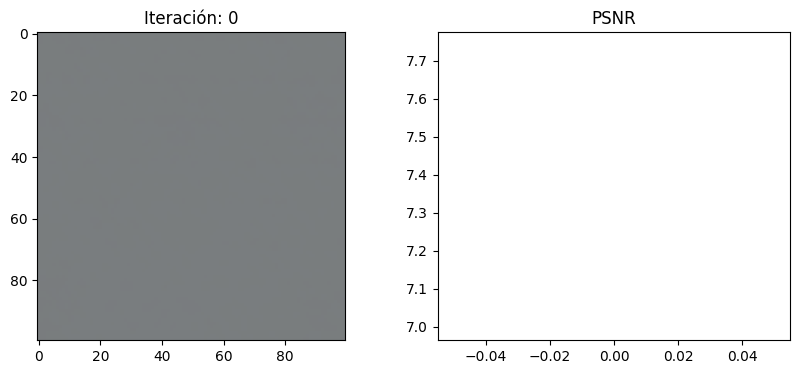

current pose:
tensor([[ 6.4665e-01, -4.1130e-01,  6.4241e-01,  2.5896e+00],
        [ 7.6279e-01,  3.4867e-01, -5.4459e-01, -2.1953e+00],
        [-1.4901e-08,  8.4218e-01,  5.3920e-01,  2.1736e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         ...,
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736]],

        [[ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         ...,
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736]],

        [[ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         ...,
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736],
         [ 2.5896, -2.1953,  2.1736]

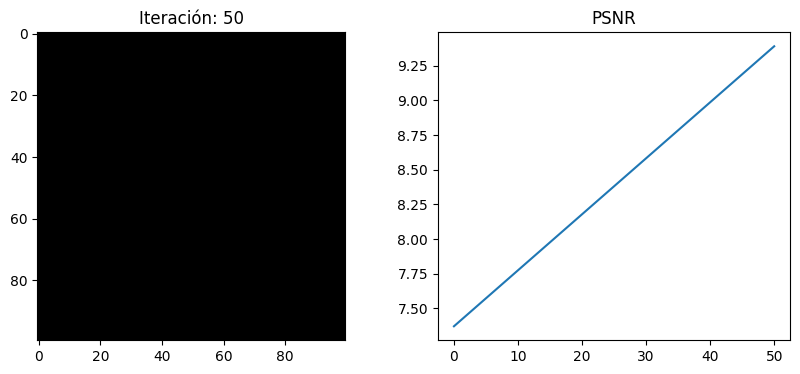

current pose:
tensor([[-2.3338e-01,  4.4257e-01, -8.6583e-01, -3.4903e+00],
        [-9.7239e-01, -1.0622e-01,  2.0780e-01,  8.3769e-01],
        [ 7.4506e-09,  8.9042e-01,  4.5513e-01,  1.8347e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         ...,
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347]],

        [[-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         ...,
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347]],

        [[-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         ...,
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347],
         [-3.4903,  0.8377,  1.8347]

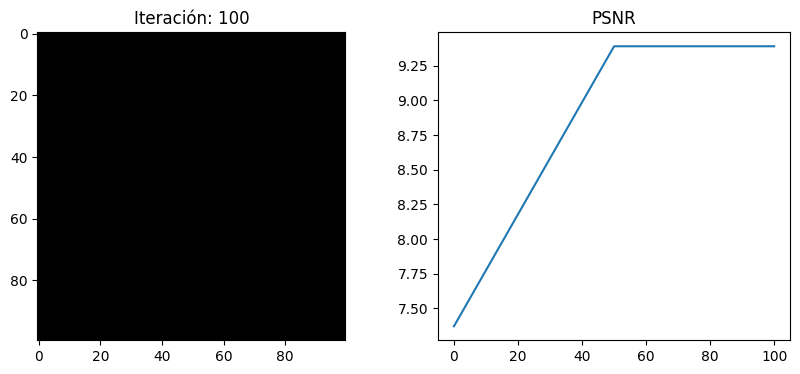

current pose:
tensor([[-0.4675,  0.5286, -0.7085, -2.8562],
        [-0.8840, -0.2796,  0.3747,  1.5106],
        [ 0.0000,  0.8015,  0.5980,  2.4105],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         ...,
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105]],

        [[-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         ...,
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105]],

        [[-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         ...,
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105],
         [-2.8562,  1.5106,  2.4105]],

        ...,

        [[-2.8562,  1.5106,  2.4105],
        

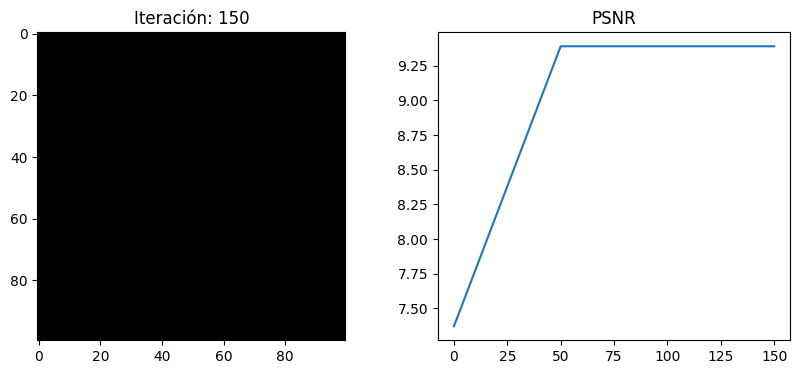

current pose:
tensor([[ 0.0844,  0.5158, -0.8525, -3.4366],
        [-0.9964,  0.0437, -0.0722, -0.2910],
        [ 0.0000,  0.8556,  0.5177,  2.0868],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         ...,
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868]],

        [[-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         ...,
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868]],

        [[-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         ...,
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868],
         [-3.4366, -0.2910,  2.0868]],

        ...,

        [[-3.4366, -0.2910,  2.0868],
        

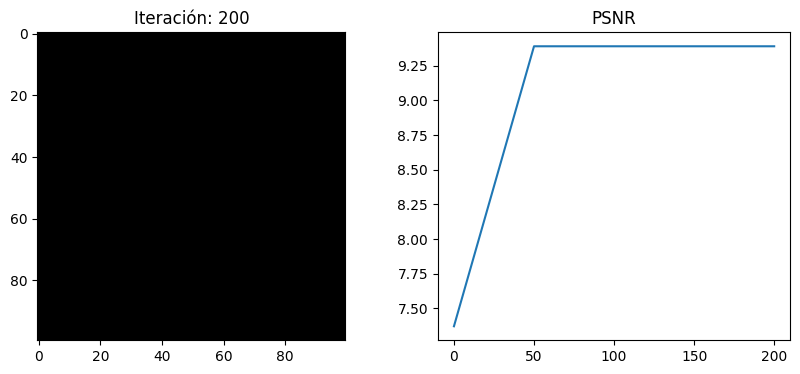

current pose:
tensor([[-0.5147,  0.4223, -0.7462, -3.0080],
        [-0.8574, -0.2535,  0.4479,  1.8057],
        [ 0.0000,  0.8703,  0.4925,  1.9853],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         ...,
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853]],

        [[-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         ...,
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853]],

        [[-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         ...,
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853]],

        ...,

        [[-3.0080,  1.8057,  1.9853],
        

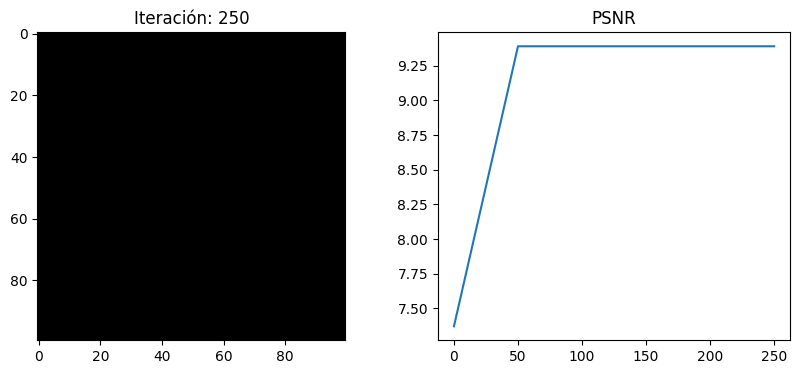

current pose:
tensor([[-9.9997e-01,  5.6572e-03, -5.1768e-03, -2.0868e-02],
        [-7.6683e-03, -7.3771e-01,  6.7507e-01,  2.7213e+00],
        [-4.6566e-10,  6.7509e-01,  7.3773e-01,  2.9739e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         ...,
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739]],

        [[-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         ...,
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739]],

        [[-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         ...,
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739],
         [-0.0209,  2.7213,  2.9739]

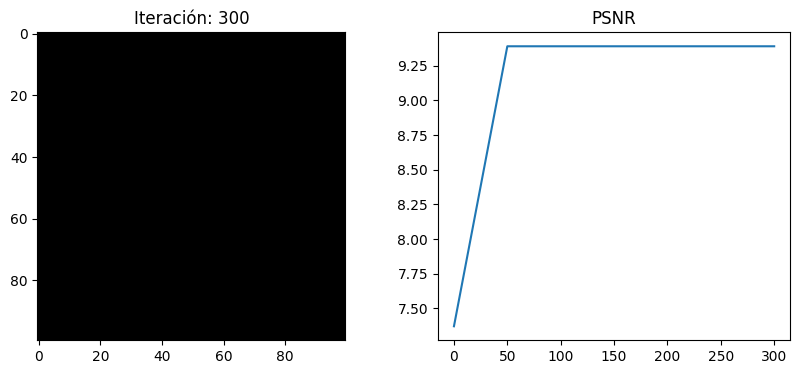

current pose:
tensor([[-9.7988e-01,  3.4005e-02, -1.9668e-01, -7.9285e-01],
        [-1.9960e-01, -1.6694e-01,  9.6555e-01,  3.8923e+00],
        [ 3.7253e-09,  9.8538e-01,  1.7037e-01,  6.8677e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         ...,
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868]],

        [[-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         ...,
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868]],

        [[-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         ...,
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868],
         [-0.7929,  3.8923,  0.6868]

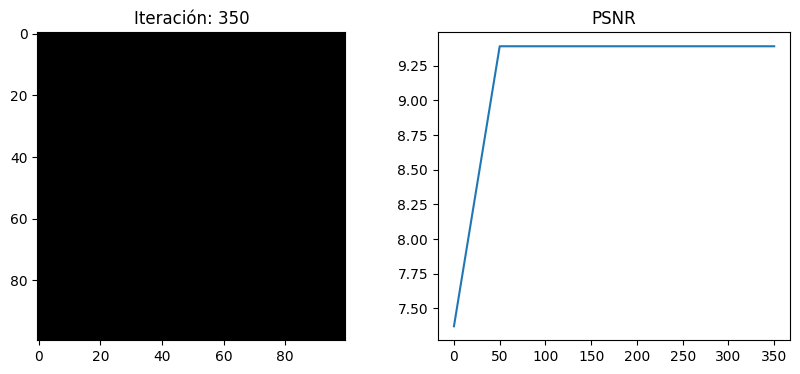

current pose:
tensor([[-0.1550,  0.9340, -0.3218, -1.2972],
        [-0.9879, -0.1466,  0.0505,  0.2035],
        [ 0.0000,  0.3257,  0.9455,  3.8113],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         ...,
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113]],

        [[-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         ...,
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113]],

        [[-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         ...,
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113],
         [-1.2972,  0.2035,  3.8113]],

        ...,

        [[-1.2972,  0.2035,  3.8113],
        

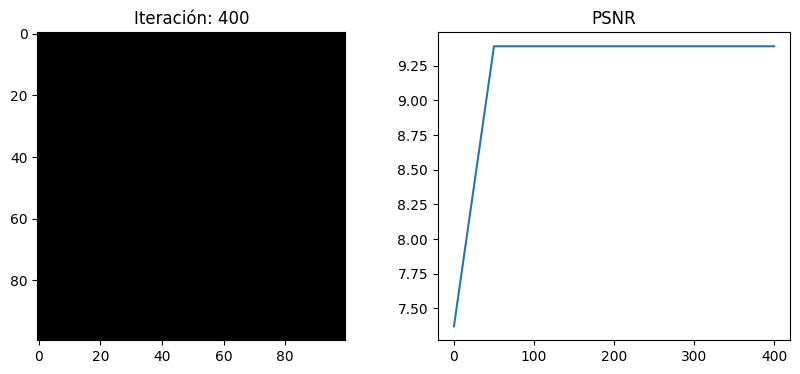

current pose:
tensor([[ 0.7740,  0.3597, -0.5212, -2.1008],
        [-0.6332,  0.4396, -0.6370, -2.5676],
        [ 0.0000,  0.8230,  0.5681,  2.2899],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         ...,
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899]],

        [[-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         ...,
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899]],

        [[-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         ...,
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899],
         [-2.1008, -2.5676,  2.2899]],

        ...,

        [[-2.1008, -2.5676,  2.2899],
        

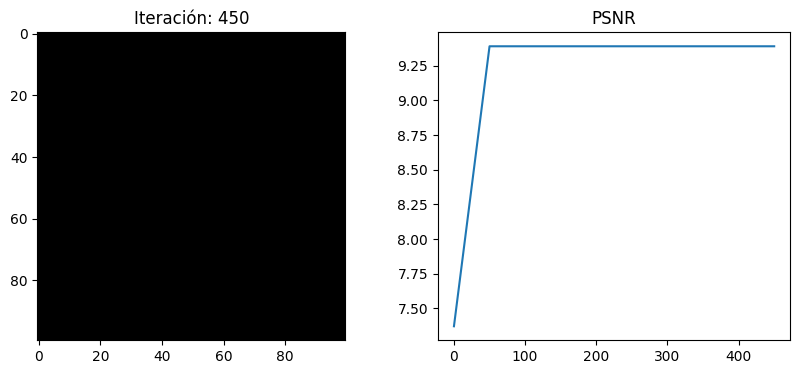

current pose:
tensor([[-0.5147,  0.4223, -0.7462, -3.0080],
        [-0.8574, -0.2535,  0.4479,  1.8057],
        [ 0.0000,  0.8703,  0.4925,  1.9853],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         ...,
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853]],

        [[-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         ...,
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853]],

        [[-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         ...,
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853],
         [-3.0080,  1.8057,  1.9853]],

        ...,

        [[-3.0080,  1.8057,  1.9853],
        

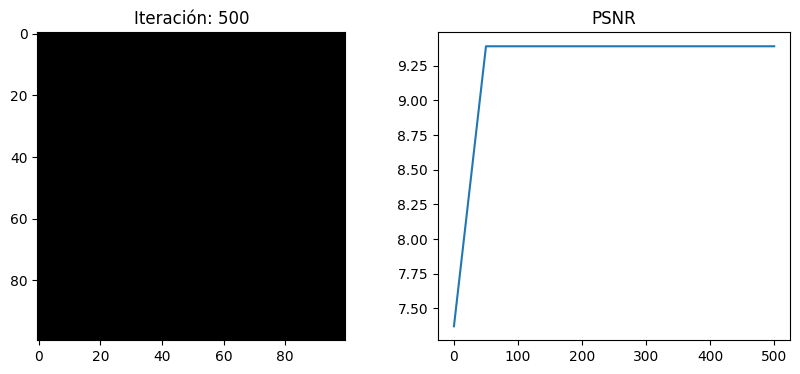

current pose:
tensor([[-2.8167e-01, -5.5048e-01,  7.8589e-01,  3.1680e+00],
        [ 9.5951e-01, -1.6160e-01,  2.3070e-01,  9.2999e-01],
        [ 2.9802e-08,  8.1906e-01,  5.7371e-01,  2.3127e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         ...,
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127]],

        [[3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         ...,
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127]],

        [[3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         ...,
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127],
         [3.1680, 0.9300, 2.3127]],

        ...,

        [[3.1680, 0.9300, 2.3127],
 

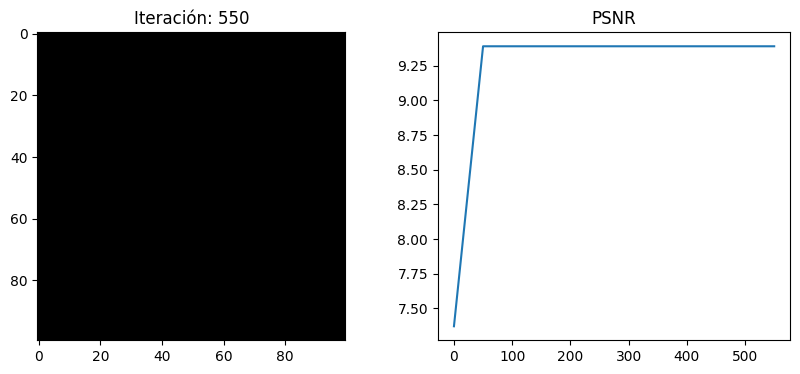

current pose:
tensor([[ 0.9514,  0.2087, -0.2264, -0.9128],
        [-0.3080,  0.6448, -0.6995, -2.8199],
        [ 0.0000,  0.7353,  0.6778,  2.7322],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         ...,
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322]],

        [[-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         ...,
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322]],

        [[-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         ...,
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322],
         [-0.9128, -2.8199,  2.7322]],

        ...,

        [[-0.9128, -2.8199,  2.7322],
        

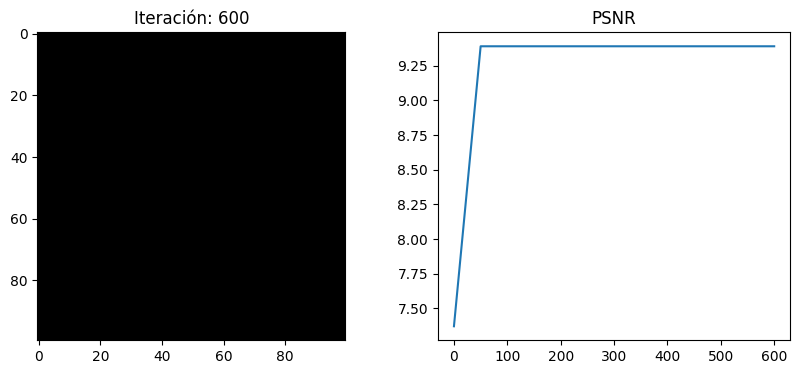

current pose:
tensor([[ 0.4535, -0.1127,  0.8841,  3.5640],
        [ 0.8913,  0.0573, -0.4498, -1.8133],
        [ 0.0000,  0.9920,  0.1264,  0.5097],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         ...,
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097]],

        [[ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         ...,
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097]],

        [[ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         ...,
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097],
         [ 3.5640, -1.8133,  0.5097]],

        ...,

        [[ 3.5640, -1.8133,  0.5097],
        

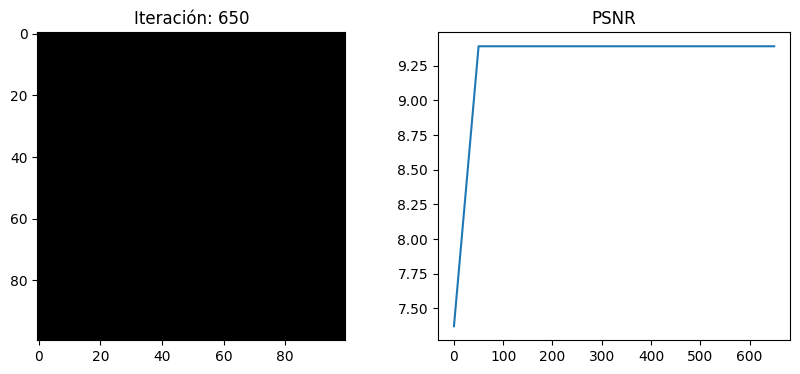

current pose:
tensor([[-3.0373e-01, -8.6047e-01,  4.0907e-01,  1.6490e+00],
        [ 9.5276e-01, -2.7431e-01,  1.3041e-01,  5.2569e-01],
        [-7.4506e-09,  4.2936e-01,  9.0313e-01,  3.6407e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         ...,
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407]],

        [[1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         ...,
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407]],

        [[1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         ...,
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407],
         [1.6490, 0.5257, 3.6407]],

        ...,

        [[1.6490, 0.5257, 3.6407],
 

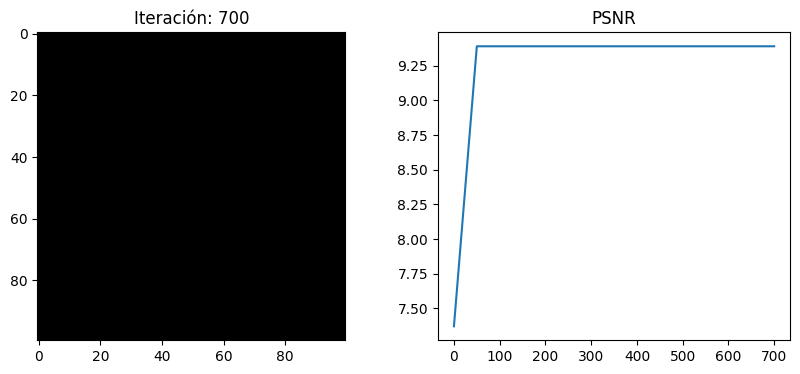

current pose:
tensor([[ 7.9598e-01, -5.3195e-01,  2.8886e-01,  1.1645e+00],
        [ 6.0532e-01,  6.9950e-01, -3.7985e-01, -1.5312e+00],
        [ 1.4901e-08,  4.7721e-01,  8.7879e-01,  3.5425e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         ...,
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425]],

        [[ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         ...,
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425]],

        [[ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         ...,
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425],
         [ 1.1645, -1.5312,  3.5425]

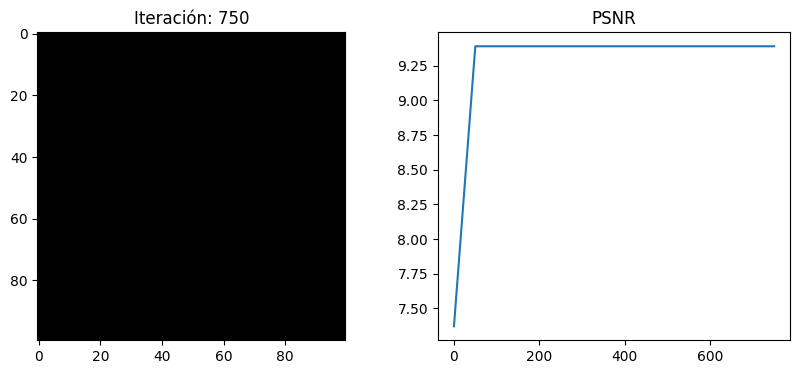

current pose:
tensor([[ 0.9978,  0.0259, -0.0610, -0.2460],
        [-0.0663,  0.3902, -0.9183, -3.7019],
        [ 0.0000,  0.9204,  0.3911,  1.5764],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         ...,
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764]],

        [[-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         ...,
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764]],

        [[-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         ...,
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764],
         [-0.2460, -3.7019,  1.5764]],

        ...,

        [[-0.2460, -3.7019,  1.5764],
        

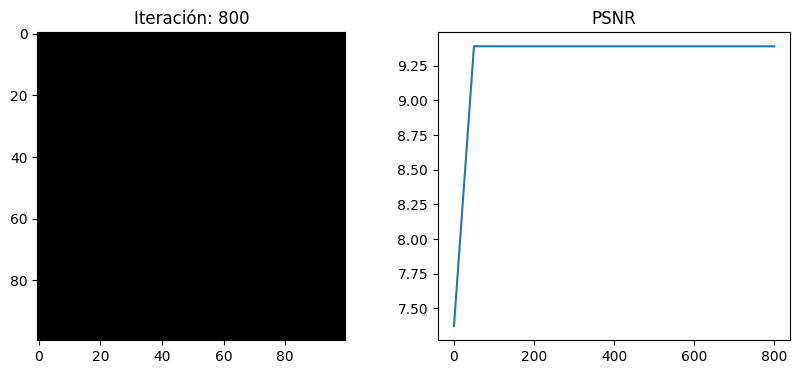

current pose:
tensor([[ 7.6567e-01, -4.7312e-01,  4.3578e-01,  1.7567e+00],
        [ 6.4323e-01,  5.6318e-01, -5.1873e-01, -2.0911e+00],
        [ 2.9802e-08,  6.7748e-01,  7.3554e-01,  2.9651e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         ...,
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651]],

        [[ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         ...,
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651]],

        [[ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         ...,
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651],
         [ 1.7567, -2.0911,  2.9651]

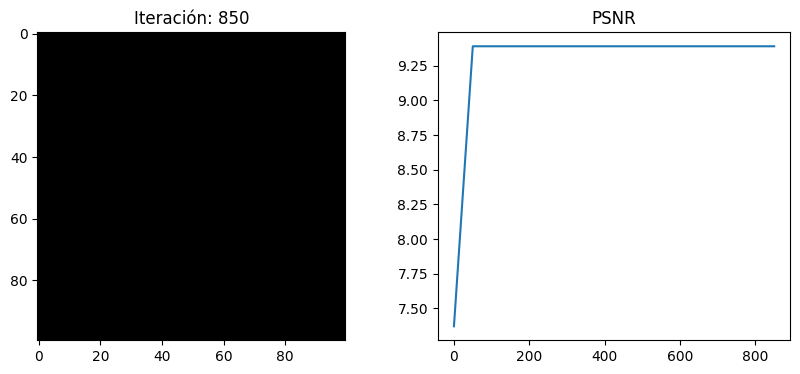

current pose:
tensor([[ 0.2325,  0.1524, -0.9606, -3.8722],
        [-0.9726,  0.0364, -0.2297, -0.9258],
        [ 0.0000,  0.9876,  0.1567,  0.6318],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         ...,
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318]],

        [[-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         ...,
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318]],

        [[-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         ...,
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318],
         [-3.8722, -0.9258,  0.6318]],

        ...,

        [[-3.8722, -0.9258,  0.6318],
        

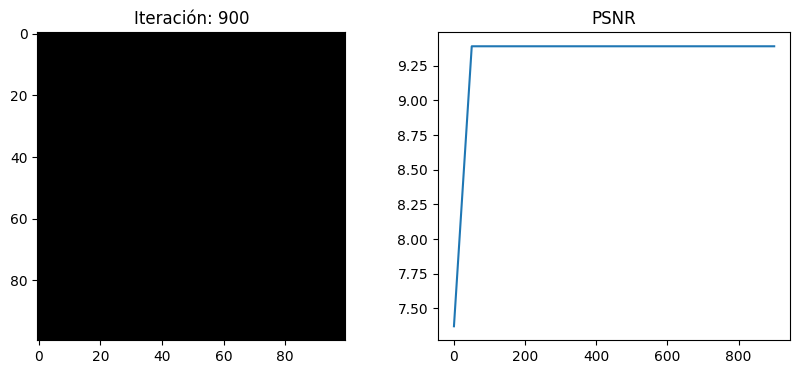

current pose:
tensor([[ 4.7694e-01,  7.4832e-01, -4.6103e-01, -1.8585e+00],
        [-8.7894e-01,  4.0606e-01, -2.5017e-01, -1.0085e+00],
        [-1.4901e-08,  5.2453e-01,  8.5139e-01,  3.4321e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])
origins:
tensor([[[-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         ...,
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321]],

        [[-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         ...,
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321]],

        [[-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         ...,
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321],
         [-1.8585, -1.0085,  3.4321]

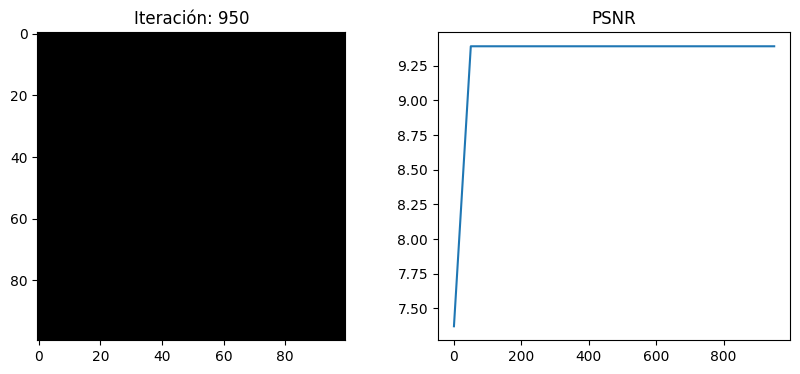

current pose:
tensor([[ 0.1600,  0.3305, -0.9302, -3.7496],
        [-0.9871,  0.0536, -0.1508, -0.6077],
        [ 0.0000,  0.9423,  0.3348,  1.3495],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])
origins:
tensor([[[-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         ...,
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495]],

        [[-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         ...,
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495]],

        [[-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         ...,
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495],
         [-3.7496, -0.6077,  1.3495]],

        ...,

        [[-3.7496, -0.6077,  1.3495],
        

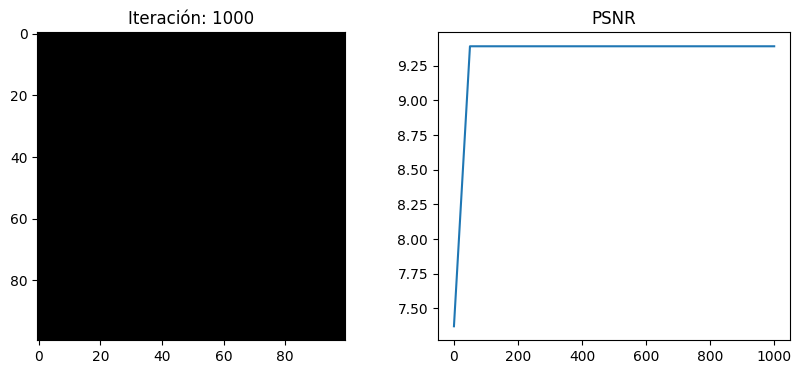

Entrenamiento finalizado
CPU times: user 9min 22s, sys: 4min 13s, total: 13min 36s
Wall time: 9min 1s


In [7]:
%%time
import torch
import torch.optim as optim
import torch.nn.functional as F
import time
import numpy as np
import matplotlib.pyplot as plt

# Inicializamos el modelo TinyNerf
modelo = TinyNerf(D=8, W=256, L_embed=6).to(device)  # Asegurarnos de que esté en el dispositivo (GPU si disponible)

# Definimos el optimizador
optimizador = optim.Adam(modelo.parameters(), lr=5e-4)

# Parámetros del entrenamiento
N_samples = 64
N_iters = 1000
psnrs = []
iternums = []
i_plot = 50

# Bucle de entrenamiento
inicio_tiempo = time.time()

# Convertir H, W y focal a tensores si aún no lo son
H = torch.tensor(H, dtype=torch.float32, device='cpu')
W = torch.tensor(W, dtype=torch.float32, device='cpu')
focal = torch.tensor(focal, dtype=torch.float32, device='cpu')
testpose = torch.tensor(testpose).to('cpu')  # La pose de la cámara

# Bucle de entrenamiento optimizado
for i in range(N_iters + 1):
    # Seleccionar una imagen aleatoria (mantener en CPU)
    img_i = np.random.randint(images.shape[0])
    objetivo = torch.tensor(images[img_i])  # Mantener objetivo en CPU
    pose = torch.tensor(poses[img_i])  # Pose en CPU

    # Obtener los rayos desde la pose actual (mantener en CPU)
    rays_o, rays_d = obtener_rayos(H, W, focal, pose)

    print("current pose:")
    print(pose)
    print("origins:")
    print(rays_o)

    # Renderizar los rayos (mantener todo en CPU excepto el modelo y puntos aplanados)
    rgb, depth, acc = renderizar_rayos(modelo, rays_o, rays_d, cerca=2., lejos=6., N_muestras=N_samples, aleatorio=True)

    # Mover la salida del modelo (RGB) a la GPU para el cálculo de la pérdida
    perdida = F.mse_loss(rgb.to(device), objetivo.to(device))

    psnr = -10. * torch.log10(perdida)
    print("loss:")
    print(perdida.item())
    print("psnr:")
    print(psnr.item())
    print("-----------------------------------------------------------------------------------")

    # Backpropagation (en GPU)
    optimizador.zero_grad()  # Limpiar los gradientes
    perdida.backward()  # Calcular los gradientes
    optimizador.step()  # Actualizar los parámetros del modelo

    # Vaciar caché después de la iteración
    torch.cuda.empty_cache()

    # Logging y visualización en CPU
    if i % i_plot == 0:
        print(f'Iteración {i}, {(time.time() - inicio_tiempo) / i_plot:.4f} segundos por iteración')
        inicio_tiempo = time.time()

        # Renderizar la vista de prueba (mantener en CPU)
        rays_o, rays_d = obtener_rayos(H.cpu(), W.cpu(), focal.cpu(), testpose.cpu())  # Todo en CPU
        rgb, depth, acc = renderizar_rayos(modelo, rays_o, rays_d, cerca=2., lejos=6., N_muestras=N_samples)

        # Calcular la pérdida en la CPU
        perdida_prueba = F.mse_loss(rgb.cpu(), torch.tensor(testimg))

        # Calcular PSNR
        psnr = -10. * torch.log10(perdida_prueba)
        psnrs.append(psnr.item())
        iternums.append(i)

        # Visualizar resultados en CPU
        plt.figure(figsize=(10, 4))
        plt.subplot(121)
        plt.imshow(rgb.cpu().detach().numpy())  # Convertir a numpy para mostrar
        plt.title(f'Iteración: {i}')
        plt.subplot(122)
        plt.plot(iternums, psnrs)
        plt.title('PSNR')
        plt.show()

    # Vaciar caché después de la iteración
    torch.cuda.empty_cache()


print('Entrenamiento finalizado')


# Visualizacion interactiva

En esta visualización interactiva, vamos a controlar la vista de la cámara sobre una escena renderizada mediante un modelo NeRF ajustando dos ángulos y un radio. Los dos ángulos, theta y phi, determinan la posición de la cámara alrededor de la escena en coordenadas esféricas, donde theta controla la rotación horizontal y phi la inclinación vertical. El parámetro de radio define la distancia de la cámara con respecto al centro de la escena. A través de deslizadores interactivos, podemos modificar estos tres parámetros en tiempo real para explorar diferentes puntos de vista de la escena renderizada, permitiendo una experiencia inmersiva para visualizar cómo el modelo NeRF genera imágenes desde diferentes posiciones de la cámara.

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive, widgets

# Transformation and rotation matrices using PyTorch
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1],
], dtype=torch.float32)

rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(torch.tensor(phi)), -torch.sin(torch.tensor(phi)), 0],
    [0, torch.sin(torch.tensor(phi)), torch.cos(torch.tensor(phi)), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

rot_theta = lambda th: torch.tensor([
    [torch.cos(torch.tensor(th)), 0, -torch.sin(torch.tensor(th)), 0],
    [0, 1, 0, 0],
    [torch.sin(torch.tensor(th)), 0, torch.cos(torch.tensor(th)), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Pose spherical function for generating camera to world matrix
def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = torch.matmul(rot_phi(phi / 180. * np.pi), c2w)
    c2w = torch.matmul(rot_theta(theta / 180. * np.pi), c2w)
    c2w = torch.matmul(torch.tensor([[-1, 0, 0, 0],
                                     [0, 0, 1, 0],
                                     [0, 1, 0, 0],
                                     [0, 0, 0, 1]], dtype=torch.float32), c2w)
    return c2w

# Function to render the scene
def f(theta, phi, radius):
    c2w = pose_spherical(theta, phi, radius)

    # Assuming obtener_rayos and renderizar_rayos are already defined
    rays_o, rays_d = obtener_rayos(H, W, focal, c2w[:3, :4].cpu())  # Obtain rays from the camera pose
    rgb, depth, acc = renderizar_rayos(modelo, rays_o, rays_d, cerca=2., lejos=6., N_muestras=N_samples)  # Render rays using the model

    img = np.clip(rgb.cpu().detach().numpy(), 0, 1)  # Clip values between 0 and 1 and move to CPU for visualization

    # Plot the image
    plt.figure(2, figsize=(20, 6))
    plt.imshow(img)
    plt.show()

# Create sliders for theta, phi, and radius
sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

# Define parameters for the interactive sliders
names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

# Create the interactive plot
interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
output = ttttttt.children[-1]
output.layout.height = '350px'
interactive_plot


interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

## Renderizar video a partir de una NeRF

Una vez que hemos entrenado un modelo NeRF (Neural Radiance Field), podemos usarlo para renderizar un video que capture una vista dinámica de la escena 3D desde diferentes ángulos. El proceso de renderizado implica generar imágenes 2D desde el modelo NeRF, proyectando la información tridimensional que ha aprendido a partir de múltiples imágenes de entrada. En este contexto, para cada frame del video, especificamos una cámara virtual con sus parámetros de proyección (intrínsecos y extrínsecos) que define desde dónde y cómo estamos viendo la escena. El modelo NeRF usa los campos de radiancia que ha entrenado para calcular cómo la luz interactúa con los objetos en la escena, y proyecta estos resultados en el plano de la imagen para producir una imagen 2D. Al generar una secuencia de imágenes desde diferentes puntos de vista, podemos ensamblarlas en un video que da la impresión de moverse a través de la escena 3D.

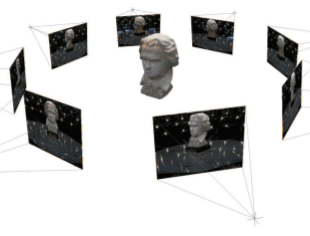

Para renderizar un video en herramientas como NeRFstudio, primero necesitamos definir una trayectoria de cámara que simule el movimiento deseado alrededor de la escena. Esta trayectoria puede ser circular o personalizada, especificando posiciones de cámara y direcciones de enfoque. Luego, ejecutamos el comando de renderizado, que genera una secuencia de imágenes basadas en la posición y orientación de la cámara en cada fotograma de la trayectoria. Una vez obtenidas todas las imágenes, podemos compilarlas en un video usando herramientas como FFmpeg o directamente dentro de Python. El resultado es una visualización impresionante de la escena 3D reconstruida, mostrando cómo el modelo NeRF ha capturado fielmente los detalles y la geometría de la escena a partir de datos de entrada 2D.

In [10]:
frames = []
with torch.no_grad():
  for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
      c2w = pose_spherical(th, -30., 4.)
      rays_o, rays_d = obtener_rayos(H, W, focal, c2w[:3,:4])
      rgb, depth, acc = renderizar_rayos(modelo, rays_o, rays_d, cerca=2., lejos=6., N_muestras=N_samples)
      frames.append((255*np.clip(rgb.detach().cpu().numpy(),0,1)).astype(np.uint8))
      # Vaciar caché después de la iteración
      torch.cuda.empty_cache()

  0%|          | 0/120 [00:00<?, ?it/s]

Guardaremos el video en la misma carpeta de este tutorial

In [11]:
import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (100, 100) to (112, 112) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[swscaler @ 0x5aff5c0] Warning: data is not aligned! This can lead to a speed loss


Visualizamos el video exportado

In [12]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)